In [ ]:
# -*- coding: utf-8 -*-
"""
Created on Mon Oct 14 14:22:15 2024

@author: avishwak
"""

import sys
from hyperelastic_SGD_Class import hyperelastic_sgd
from hyperelastic_SGD_Class import Ogden_base_model
from hyperelastic_SGD_Class import Ogden_Order3

import torch.nn as nn
import pandas as pd
import matplotlib.pylab as plt
import numpy as np

import torch
import torch.nn as nn
import torch.optim as optim


import os
os.environ["OMP_NUM_THREADS"] = "1" 

Ogden3:tensor_inherited_class_in_work


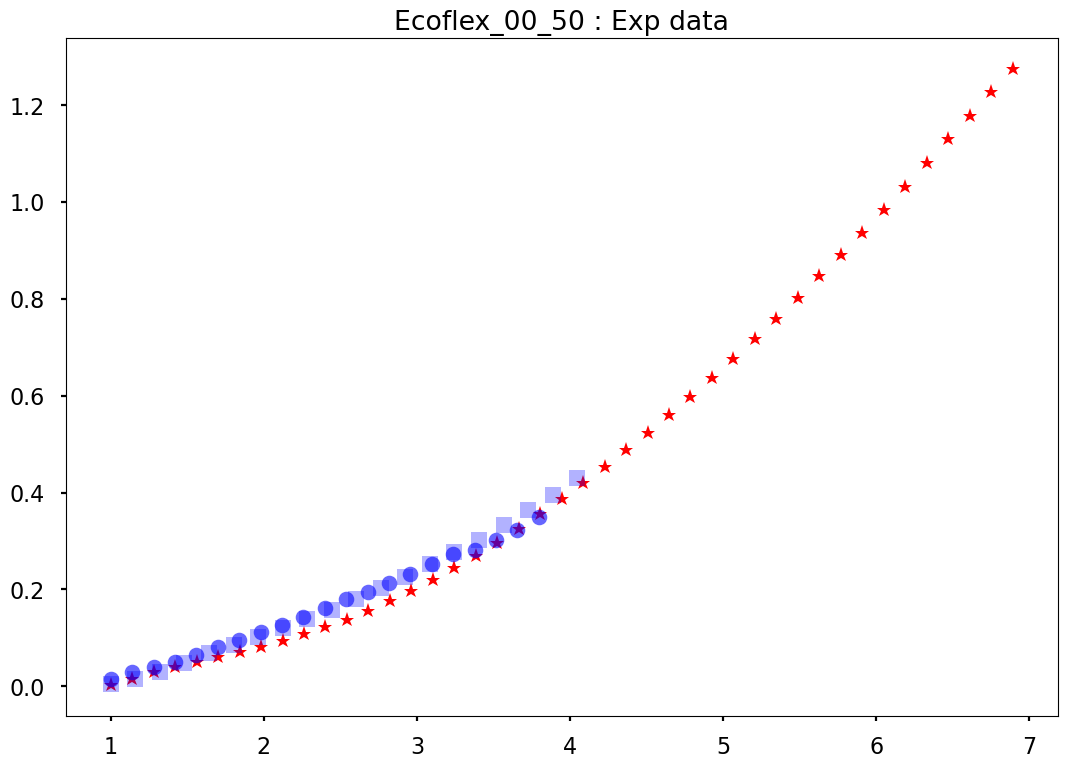

In [2]:
#%% import data
name = str('Ecoflex_00_50')
df = pd.read_excel('./' + name + '.xlsx')
#Uniaxial
column_a = df['stretch_ut']
tensor_a = torch.tensor(column_a.values, dtype=torch.float32)
exp_stretch_ut = tensor_a[~torch.isnan(tensor_a)]
exp_stretch_ut = exp_stretch_ut.numpy()

column_a = df['stress_ut']
tensor_a = torch.tensor(column_a.values, dtype=torch.float32)
exp_stress_ut = tensor_a[~torch.isnan(tensor_a)]
exp_stress_ut = exp_stress_ut.numpy()



#Planar 50
column_a = df['stretch_pl_50mm']
tensor_a = torch.tensor(column_a.values, dtype=torch.float32)
exp_stretch_pl_50 = tensor_a[~torch.isnan(tensor_a)]
exp_stretch_pl_50 = exp_stretch_pl_50.numpy()

column_a = df['stress_pl_50mm']
tensor_a = torch.tensor(column_a.values, dtype=torch.float32)
exp_stress_pl_50 = tensor_a[~torch.isnan(tensor_a)]
exp_stress_pl_50 = exp_stress_pl_50.numpy()


#Planar 70
column_a = df['stretch_pl_70mm']
tensor_a = torch.tensor(column_a.values, dtype=torch.float32)
exp_stretch_pl_70 = tensor_a[~torch.isnan(tensor_a)]
exp_stretch_pl_70 = exp_stretch_pl_70.numpy()

column_a = df['stress_pl_70mm']
tensor_a = torch.tensor(column_a.values, dtype=torch.float32)
exp_stress_pl_70 = tensor_a[~torch.isnan(tensor_a)]
exp_stress_pl_70 = exp_stress_pl_70.numpy()

plt.style.use('seaborn-v0_8-poster')
plt.title(name + ' : Exp data')
interval= 40
plt.plot(exp_stretch_ut[::interval], exp_stress_ut[::interval],'*r', label = 'Uniaxial')
interval= 80
plt.plot(exp_stretch_pl_50[::interval], exp_stress_pl_50[::interval], 'bs', alpha = 0.3 , label = 'Planar 50mm')
plt.plot(exp_stretch_pl_70[::interval], exp_stress_pl_70[::interval], 'bo', alpha = 0.6 ,label = 'Planar 70mm')

plt.show()


Initial Guess : [μ1, μ2, μ3, α1, α2, α3] =  [0.1 0.1 0.1 0.1 0.1 0.1]


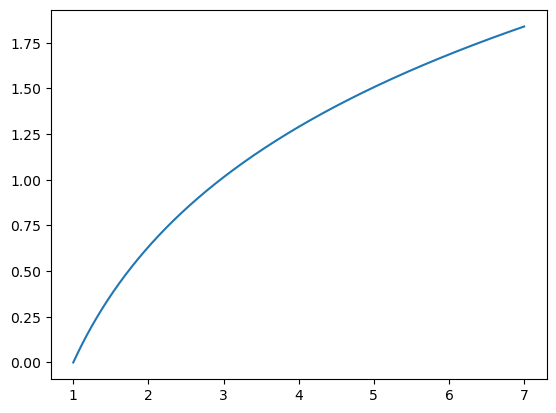

In [3]:
# for manual custom invoking of the function with a custom initial guess parameters: 
# initial guess
initial_guess = [0.1,0.1,0.1,0.1,0.1,0.1]

# create class instance
Ogden3 = hyperelastic_sgd('Ogden',initial_guess,3,exp_stretch_ut,exp_stress_ut)
#call for Ogden model order 3 and find stress values for given stretch and initial parameters

theo_stress_ut = Ogden3.OgdenModel(initial_guess,exp_stretch_ut,loading_type='uniaxial')
theo_stress_pl_50 = Ogden3.OgdenModel(initial_guess,exp_stretch_pl_50,loading_type='planar')
theo_stress_pl_70 = Ogden3.OgdenModel(initial_guess,exp_stretch_pl_70,loading_type='planar')
plt.style.use('default') 

plt.figure()
plt.plot(exp_stretch_ut,theo_stress_ut)
plt.show()

In [ ]:
x_ten1 = torch.tensor(exp_stretch_ut, dtype=torch.float32)
x_ten2 = torch.tensor(exp_stretch_pl_50, dtype=torch.float32)
x_ten3 = torch.tensor(exp_stretch_pl_70, dtype=torch.float32)

y_ten1 = torch.tensor(exp_stress_ut, dtype=torch.float32)
y_ten2 = torch.tensor(exp_stress_pl_50, dtype=torch.float32)
y_ten3 = torch.tensor(exp_stress_pl_70, dtype=torch.float32)

tot_len = len(x_ten1) + len(x_ten2) + len(x_ten3)


# create instance of the model
base = Ogden_base_model()
Og3 = Ogden_Order3(base)

# define the loss function (i.e. MSE)
criterion = nn.MSELoss()

# define the optimizer (i.e. SGD)
optimizer = optim.SGD(base.parameters(), lr=0.01, momentum=0.9)  

Loss_cml = np.array([]) # cumulative loss 
n_epochs = 100_000  

###########################################


# Set the checkpoint file path
checkpoint_path = './data/Ogden3.pth'
loss_history = []  # for checkpoint

# If a checkpoint exists, load it else start training from scratch
if os.path.exists(checkpoint_path):
    checkpoint = torch.load(checkpoint_path)
    base.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    start_epoch = checkpoint.get('epoch', 0) + 1
    loss_history = checkpoint.get('loss_history', [])
    print(f"Resuming training from epoch {start_epoch}")
else:
    start_epoch = 0
    print("Starting training from scratch.")
###########################################


for epoch in range(start_epoch, n_epochs):
    # Forward pass for both models
    y_pred1 = Og3(x_ten1, 3, 'uniaxial')
    y_pred2 = Og3(x_ten2, 3, 'planar')
    y_pred3 = Og3(x_ten3, 3, 'planar')
    
    # Compute combined loss with equal weighting for each data point
    loss1 = criterion(y_pred1, y_ten1)*len(x_ten1)/tot_len
    loss2 = criterion(y_pred2, y_ten2)*len(x_ten2)/tot_len   
    loss3 = criterion(y_pred3, y_ten3)*len(x_ten3)/tot_len   
    loss = loss1 + loss2 + loss3  
    
    Loss_cml = np.append(Loss_cml,loss.detach().numpy()) #append cumulative loss
    
    loss_history.append(loss.item())  # for checkpoint

    # Zero gradients before the backward pass
    optimizer.zero_grad()
    
    # compute gradients for Backward pass 
    loss.backward()
    
    # SGD: update parameters
    optimizer.step()
    ### custom_optimizer_step()
    

    if (epoch) % 10_000 == 0:
        print(f'Epoch [{epoch + 1}/{n_epochs}], Loss: {loss.item():.4f}')
        plt.figure()
        plt.scatter(x_ten1, y_ten1.detach().numpy().T, label = 'Experiment (Uniaxial)',alpha = 0.01)
        plt.scatter(x_ten2, y_ten2.detach().numpy().T, label = 'Experiment (Planar 50mm)',alpha = 0.01)
        plt.scatter(x_ten3, y_ten3.detach().numpy().T, label = 'Experiment (Planar 70mm)',alpha = 0.01)
        plt.plot(x_ten1, y_pred1.detach().numpy().T,label = 'SGD Optimizer Unixial')
        plt.plot(x_ten2, y_pred2.detach().numpy().T,label = 'SGD Optimizer Planar 50mm')  #ani
        plt.plot(x_ten3, y_pred3.detach().numpy().T,label = 'SGD Optimizer Planar 70mm')  #ani
        plt.legend(loc = 'best')
        plt.show()



        ##################### save checkpoint at end  ################
        checkpoint = {
            'model_state_dict': base.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'epoch': epoch,
            'loss_history': loss_history,
        } # for checkpoint
        torch.save(checkpoint, checkpoint_path)  # for checkpoint
        print(f"Checkpoint saved at epoch {epoch}")# for checkpoint
    


Resuming training from epoch 90001


d:\0_Github\5_MofM_manuscript_submis__data\Z_Selected\Algorithm_sgd\hyperelastic_SGD_Class.py:190: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  stretch = torch.tensor(stretch, dtype=torch.float32)
d:\0_Github\5_MofM_manuscript_submis__data\Z_Selected\Algorithm_sgd\hyperelastic_SGD_Class.py:179: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  stretch = torch.tensor(stretch, dtype=torch.float32)
c:\ProgramData\Anaconda3\Lib\site-packages\torch\nn\modules\loss.py:535: UserWarning: Using a target size (torch.Size([1712])) that is different to the input size (torch.Size([1, 1712])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return 

In [5]:
#%% Get the learned parameters from the base model
μ1, μ2, μ3 = base.μ1.item(), base.μ2.item(), base.μ3.item()
α1, α2, α3 = base.α1.item(), base.α2.item(), base.α3.item()
print(f"Learned parameters: μ1 = {μ1}, μ2 = {μ2}, μ3 = {μ3}")
print(f"Learned parameters: α1 = {α1}, α2 = {α2}, α3 = {α3}")

Learned parameters: μ1 = 0.17390616238117218, μ2 = 0.0996212363243103, μ3 = -0.24525241553783417
Learned parameters: α1 = 0.7230112552642822, α2 = 1.7066452503204346, α3 = 1.0900945663452148


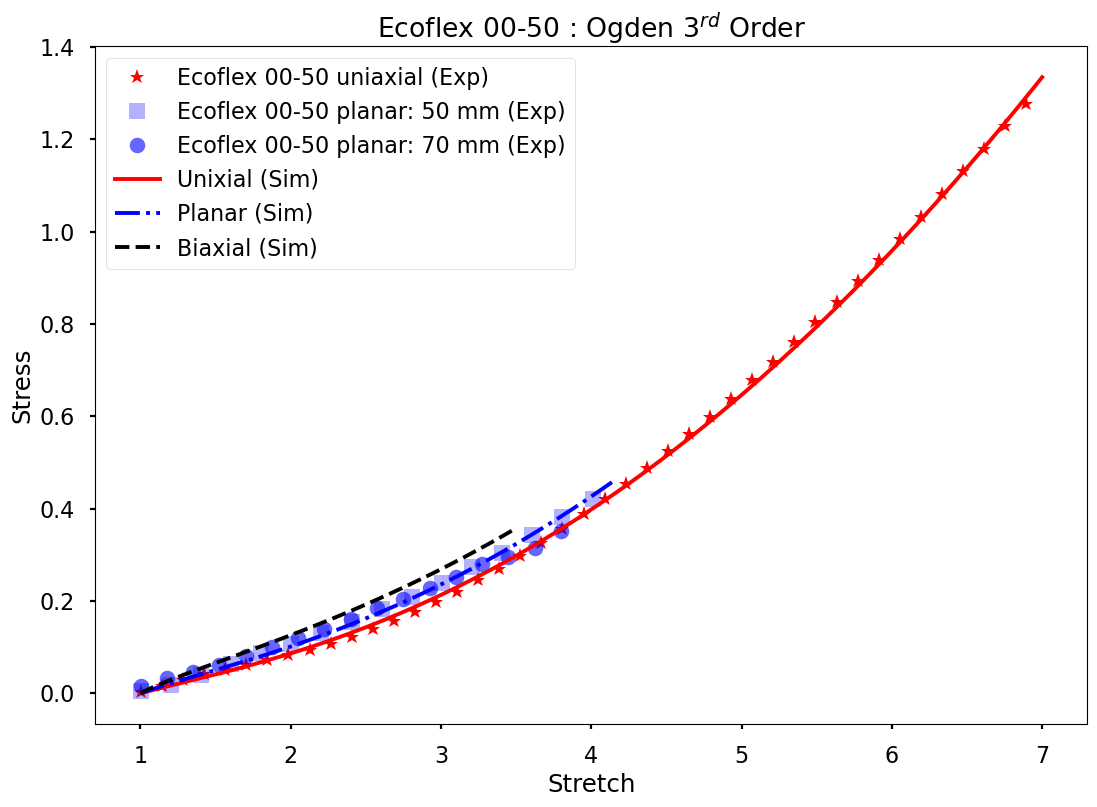

In [6]:
from mpl_toolkits.axes_grid1.inset_locator import (inset_axes, InsetPosition,mark_inset)

len = np.arange(n_epochs)

plt.style.use('seaborn-v0_8-poster')

fig,ax1 = plt.subplots()
plt.style.use('seaborn-v0_8-poster')
plt.title('Ecoflex 00-50 : Ogden 3$^{rd}$ Order')


interval = 40
ax1.plot(x_ten1[1::interval], y_ten1.detach().numpy().T[1::interval], 'r*', label = 'Ecoflex 00-50 uniaxial (Exp)')
interval = 100
ax1.plot(x_ten2[1::interval] , y_ten2.detach().numpy().T[1::interval] , 'bs', alpha = 0.3, label = 'Ecoflex 00-50 planar: 50 mm (Exp)')
ax1.plot(x_ten3[1::interval] , y_ten3.detach().numpy().T[1::interval] , 'bo', alpha = 0.6, label = 'Ecoflex 00-50 planar: 70 mm (Exp)')

ax1.plot(x_ten1, y_pred1.detach().numpy().T, 'r-' ,label = 'Unixial (Sim)')
ax1.plot(x_ten2, y_pred2.detach().numpy().T, 'b-.' ,label = 'Planar (Sim)')

strain_biaxial = np.linspace(1,3.5,100)   # create strain vect for a given range to predict the biaxial stress 

params = [μ1, μ2, μ3, α1, α2, α3]
biax_theo = Ogden3.OgdenModel(params,np.array(strain_biaxial), 'biaxial').detach().numpy()
ax1.plot(strain_biaxial,biax_theo, 'k--' ,label = 'Biaxial (Sim)')
ax1.legend(loc = 'upper left')
ax1.set_xlabel('Stretch')
ax1.set_ylabel('Stress')
plt.show()
